# Single-Cell Analysis of Malva Quantification

This notebook performs standard single-cell analysis on the gene expression
data generated by `malva quant`. We will:

1. Load the pseudoquantification results
2. Filter cells and genes by quality metrics
3. Normalize and identify highly variable genes
4. Cluster cells and visualize with UMAP
5. Identify marker genes for each cluster

**Prerequisites:** Run `1_run_malva.sh` first to generate the input files.

## Load the data

In [2]:
import scanpy as sc
import matplotlib.pyplot as plt

In [ ]:
# Load the h5ad file generated by malva quant
adata = sc.read_h5ad("quant/pbmc_1k_v3/pseudoquant.h5ad")
adata.var_names_make_unique()

print(f"Loaded {adata.n_obs} cells and {adata.n_vars} genes")

In [ ]:
# Calculate QC metrics: total counts and genes detected per cell
sc.pp.calculate_qc_metrics(adata, inplace=True)

# Filter out low-quality cells and rarely detected genes
sc.pp.filter_cells(adata, min_genes=1200)
sc.pp.filter_genes(adata, min_cells=10)

print(f"After filtering: {adata.n_obs} cells and {adata.n_vars} genes")

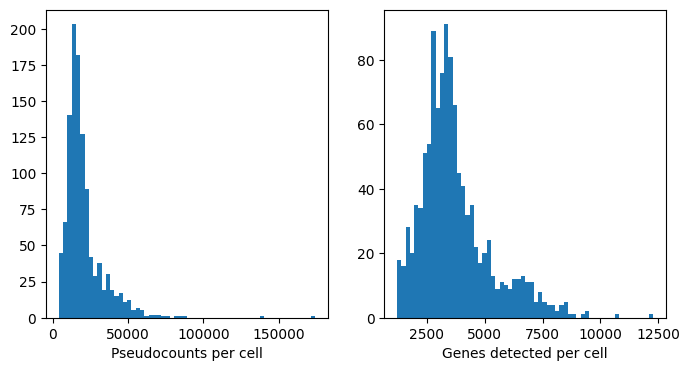

In [ ]:
# Visualize QC distributions
fig, axs = plt.subplots(1, 2, figsize=(8, 4))
axs[0].hist(adata.obs["total_counts"], bins=60)
axs[1].hist(adata.obs["n_genes_by_counts"], bins=60)
axs[0].set_xlabel("Pseudocounts per cell")
axs[1].set_xlabel("Genes detected per cell")
plt.show()

## Normalization and feature selection

In [ ]:
# Standard log-normalization
sc.pp.normalize_total(adata, inplace=True)
sc.pp.log1p(adata)

In [ ]:
# Select highly variable genes for dimensionality reduction
sc.pp.highly_variable_genes(adata, flavor="seurat", n_top_genes=2000)

## Dimensionality reduction and clustering

In [ ]:
# PCA, neighbor graph, and Leiden clustering
sc.pp.pca(adata)
sc.pp.neighbors(adata)
sc.tl.leiden(adata, resolution = 0.9, key_added="leiden")
sc.tl.umap(adata)

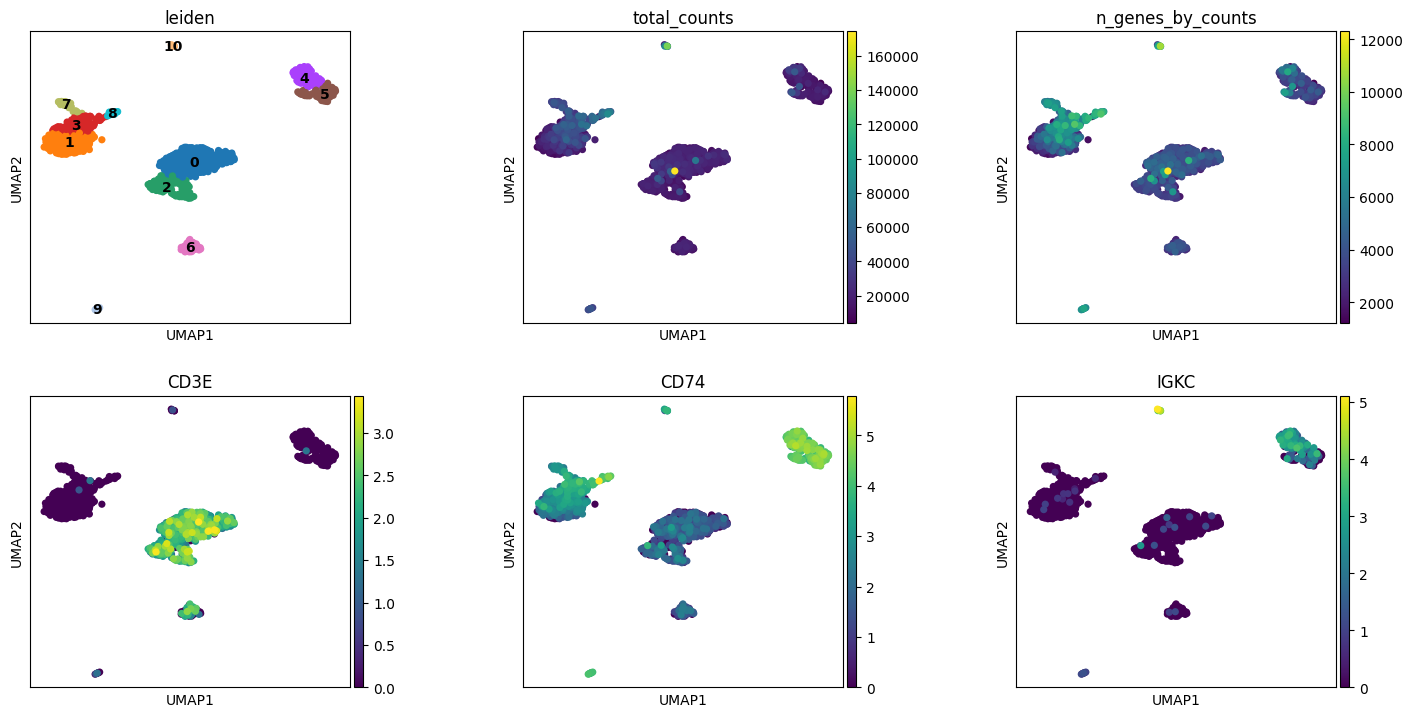

In [ ]:
# Visualize clusters and key PBMC markers
# CD3E: T cells, CD74: antigen-presenting cells, IGKC: B cells

plt.rcParams["figure.figsize"] = (4, 4)
sc.pl.umap(adata, color=["leiden", "total_counts", "n_genes_by_counts", "CD3E", "CD74", "IGKC"], wspace=0.4, ncols=3, legend_loc = "on data")

## Marker gene identification

In [ ]:
# Find differentially expressed genes for each cluster
sc.tl.rank_genes_groups(adata, 'leiden')
sc.tl.dendrogram(adata, 'leiden')

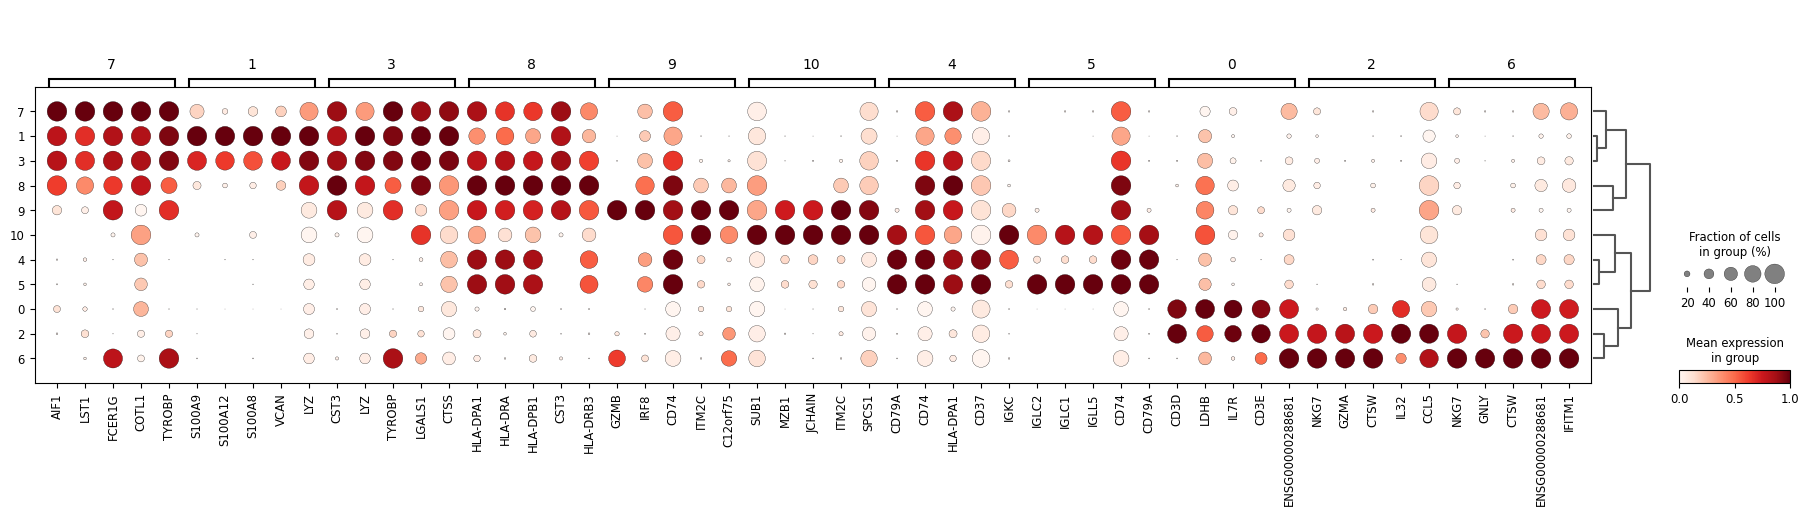

In [ ]:
# Dotplot of top marker genes per cluster
sc.pl.rank_genes_groups_dotplot(adata, n_genes=5, standard_scale='var', min_logfoldchange=2)

## Save results for sequence search

We save the clustered data for use in the next notebook.

In [ ]:
adata.write_h5ad("quant/pbmc_1k_v3/pseudoquant_clustered.h5ad")